# PHÂN TÍCH DỮ LIỆU ĐƠN HÀNG THƯƠNG MẠI ĐIỆN TỬ 2026

**Hướng triển khai:** Dự án portfolio lấy SQL làm trung tâm  
**Công cụ chính:** SQL Server + Google Colab  
**Tên cột:** Việt hóa dạng `snake_case` để người đọc ít tiếng Anh dễ theo dõi

**Python:** chỉ dùng để kết nối SQL, nhận kết quả và trực quan hóa.

## Mục tiêu
1. Kiểm tra cấu trúc và chất lượng dữ liệu.
2. Đánh giá doanh thu, lợi nhuận và xu hướng theo thời gian.
3. Phân tích sản phẩm, khách hàng, giảm giá và vận chuyển.
4. Phân nhóm khách hàng bằng các quy tắc kinh doanh viết bằng SQL.
5. Tổng hợp nhận định và đề xuất có thể hành động.

> Bố cục: **Hiểu bài toán kinh doanh → Hiểu dữ liệu → Chất lượng dữ liệu → EDA → Phân tích khách hàng → Nhận định kinh doanh → Kết luận**



## Mục lục

1. Khai báo môi trường và kết nối SQL Server  
2. Tổng quan và hiểu dữ liệu  
3. Kiểm tra chất lượng dữ liệu  
4. Phân tích khám phá dữ liệu theo câu hỏi kinh doanh  
5. Phân nhóm khách hàng bằng SQL  
6. Nhận định kinh doanh  
7. Kết luận và hướng phát triển

# PHẦN 1. KHAI BÁO MÔI TRƯỜNG VÀ KẾT NỐI SQL SERVER

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

### Nhận xét
Cell này nạp các thư viện cần thiết cho dự án:
- `pandas`: nhận kết quả truy vấn SQL dưới dạng bảng.
- `matplotlib`: vẽ biểu đồ.
- `SQLAlchemy`: tạo kết nối tới SQL Server.
- `quote_plus`: mã hóa chuỗi kết nối để tránh lỗi ký tự đặc biệt.


In [2]:
TEN_COT_SQL = {
    'Order_ID': 'ma_don_hang',
    'Customer_ID': 'ma_khach_hang',
    'Order_Date': 'ngay_dat_hang',
    'Year': 'nam',
    'Month': 'thang',
    'Day': 'ngay',
    'Day_Of_Week': 'thu_trong_tuan',
    'Quarter': 'quy',
    'Customer_Age': 'tuoi_khach_hang',
    'Customer_Gender': 'gioi_tinh_khach_hang',
    'Country': 'quoc_gia',
    'City': 'thanh_pho',
    'Customer_Segment': 'phan_khuc_khach_hang',
    'Product_ID': 'ma_san_pham',
    'Product_Category': 'nhom_san_pham',
    'Product_Subcategory': 'phan_nhom_san_pham',
    'Brand': 'thuong_hieu',
    'Unit_Price': 'don_gia',
    'Quantity': 'so_luong',
    'Discount_Percent': 'ty_le_giam_gia',
    'Discount_Amount': 'tien_giam_gia',
    'Coupon_Used': 'da_dung_ma_giam_gia',
    'Shipping_Cost': 'chi_phi_van_chuyen',
    'Tax_Amount': 'tien_thue',
    'Order_Amount': 'tong_tien',
    'Payment_Method': 'phuong_thuc_thanh_toan',
    'Device_Type': 'loai_thiet_bi',
    'Traffic_Source': 'nguon_truy_cap',
    'Membership_Status': 'trang_thai_thanh_vien',
    'Shipping_Method': 'phuong_thuc_van_chuyen',
    'Warehouse_Region': 'khu_vuc_kho',
    'Delivery_Days': 'so_ngay_giao_hang',
    'Order_Status': 'trang_thai_don_hang',
    'Returned': 'da_tra_hang',
    'Review_Rating': 'danh_gia',
    'Customer_Lifetime_Value': 'gia_tri_vong_doi_khach_hang',
    'Profit_Margin_Percent': 'bien_loi_nhuan',
    'Profit_Amount': 'loi_nhuan',
    'Season': 'mua',
    'Holiday_Season': 'mua_le_hoi',
    'High_Value_Order': 'don_hang_gia_tri_cao',
}

def hien_thi_vi(df):
    return df


### Nhận xét
Cell này khai báo từ điển đổi tên **cột thật** trong SQL Server sang tiếng Việt dạng `snake_case` và giữ lại hàm `hien_thi_vi()` để không phải thay đổi cấu trúc các cell phân tích.


## 1.1. Kết nối SQL Server


In [3]:
DB_USER = "db63421"
DB_PASSWORD = "sonle2k4"
DB_HOST = "db63421.public.databaseasp.net"
DB_PORT = "1433"
DB_NAME = "db63421"

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={DB_HOST},{DB_PORT};"
    f"DATABASE={DB_NAME};"
    f"UID={DB_USER};"
    f"PWD={DB_PASSWORD};"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
    "Connection Timeout=30;"
)

params = quote_plus(connection_string)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    pool_pre_ping=True
)

try:
    with engine.connect() as conn:
        ten_database = conn.execute(text("SELECT DB_NAME()")).scalar()
        print("Kết nối thành công!")
        print("Database hiện tại:", ten_database)

except Exception as loi:
    print("Kết nối thất bại:")
    print(loi)

Kết nối thành công!
Database hiện tại: db63421


### Nhận xét
- Kết nối tới database **`db63421` đã thành công**.

## 1.2. Khai báo bảng

Chỉ cần sửa `TABLE_ONLY` đúng bằng tên bảng hiện tại.  
Schema giữ theo đúng kiểu cậu đang dùng: `[dbo].[ten_bang]`.

In [4]:
TABLE_SCHEMA = "dbo"
TABLE_ONLY = "ecommerce_orders_dataset"

TABLE_NAME = f"[{TABLE_SCHEMA}].[{TABLE_ONLY}]"

print("Bảng đang phân tích:", TABLE_NAME)

Bảng đang phân tích: [dbo].[ecommerce_orders_dataset]


## 1.3. Việt hóa tên cột trong bảng SQL



In [5]:

with engine.begin() as conn:
    danh_sach_cot_hien_tai = {
        row[0]
        for row in conn.execute(
            text(f'''
                SELECT COLUMN_NAME
                FROM INFORMATION_SCHEMA.COLUMNS
                WHERE TABLE_SCHEMA = :schema
                  AND TABLE_NAME = :table
            '''),
            {"schema": TABLE_SCHEMA, "table": TABLE_ONLY}
        )
    }

    for ten_cot_cu, ten_cot_moi in TEN_COT_SQL.items():
        if ten_cot_cu in danh_sach_cot_hien_tai:
            conn.execute(
                text(
                    f"EXEC sp_rename "
                    f"N'{TABLE_SCHEMA}.{TABLE_ONLY}.{ten_cot_cu}', "
                    f"N'{ten_cot_moi}', 'COLUMN'"
                )
            )

print("Đã kiểm tra và Việt hóa tên cột trong bảng SQL.")


Đã kiểm tra và Việt hóa tên cột trong bảng SQL.


### Nhận xét
- Cell này thay **tên cột thật trong SQL Server**, không chỉ đổi tên khi hiển thị.
- Ví dụ: `Order_ID` thành `ma_don_hang`, `Order_Amount` thành `tong_tien`, `Review_Rating` thành `danh_gia`.


### Nhận xét
Notebook đang phân tích bảng **`[dbo].[ecommerce_orders_dataset]`**. Việc tách `TABLE_SCHEMA`, `TABLE_ONLY` và `TABLE_NAME` giúp đổi bảng phân tích mà không phải sửa lại toàn bộ câu SQL phía dưới.

# PHẦN 2. TỔNG QUAN VÀ HIỂU DỮ LIỆU

## 2.1. Danh sách cột và kiểu dữ liệu

In [6]:
query = f'''
SELECT
    COLUMN_NAME AS ten_cot,
    DATA_TYPE AS kieu_du_lieu
FROM INFORMATION_SCHEMA.COLUMNS
WHERE TABLE_SCHEMA = '{TABLE_SCHEMA}'
  AND TABLE_NAME = '{TABLE_ONLY}'
ORDER BY ORDINAL_POSITION
'''

df_columns = pd.read_sql(query, engine)
df_columns_hien_thi = df_columns.copy()

hien_thi_vi(df_columns_hien_thi)


,ten_cot,kieu_du_lieu
0,ma_don_hang,int
1,ma_khach_hang,nvarchar
2,ngay_dat_hang,date
3,nam,smallint
4,thang,tinyint
5,ngay,tinyint
6,thu_trong_tuan,nvarchar
7,quy,tinyint
8,tuoi_khach_hang,tinyint
9,gioi_tinh_khach_hang,nvarchar


### Nhận xét
- Bảng có **41 cột**.
- Dữ liệu gồm nhiều nhóm thông tin: thời gian, khách hàng, sản phẩm, giá/giảm giá, thanh toán, vận chuyển, đánh giá và lợi nhuận.
- Tên cột trong database đã để tiếng Anh để SQL chạy đúng; notebook bổ sung phần hiển thị tiếng Việt để người đọc dễ hiểu hơn.

### Nhận xét tổng quan cấu trúc dữ liệu
- Tổng số cột: **41**.
- Nhóm thời gian: ngày đặt hàng, năm, tháng, ngày, thứ, quý, mùa.
- Nhóm khách hàng: mã khách, tuổi, giới tính, quốc gia, thành phố, phân khúc, trạng thái thành viên, CLV.
- Nhóm sản phẩm: mã sản phẩm, nhóm, phân nhóm, thương hiệu, đơn giá, số lượng.
- Nhóm tài chính: giảm giá, thuế, giá trị đơn, lợi nhuận, biên lợi nhuận.
- Nhóm trải nghiệm/vận chuyển: phương thức vận chuyển, kho, số ngày giao, trạng thái đơn, trả hàng, điểm đánh giá.

## 2.2. Xem 5 dòng đầu

In [7]:
query = f'''
SELECT TOP 5
    *
FROM {TABLE_NAME}
'''

df_head = pd.read_sql(query, engine)
hien_thi_vi(df_head)

,ma_don_hang,ma_khach_hang,ngay_dat_hang,nam,thang,ngay,thu_trong_tuan,quy,tuoi_khach_hang,gioi_tinh_khach_hang,...,so_ngay_giao_hang,trang_thai_don_hang,da_tra_hang,danh_gia,gia_tri_vong_doi_khach_hang,bien_loi_nhuan,loi_nhuan,mua,mua_le_hoi,don_hang_gia_tri_cao
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,...,2,Delivered,False,44.0,214492.0,231.0,1575.0,Winter,False,False
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,...,9,Delivered,False,41.0,81717.0,857.0,332.0,Winter,False,False
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,...,2,Delivered,False,50.0,54116.0,2972.0,4567.0,Winter,False,False
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,...,6,Returned,True,34.0,70049.0,2522.0,7525.0,Winter,False,False
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,...,8,Delivered,False,36.0,213377.0,2464.0,2606.0,Winter,False,False


### Nhận xét
- 5 dòng đầu cho thấy dữ liệu có **41 cột** và chứa đầy đủ thông tin từ đơn hàng đến khách hàng, sản phẩm và logistics.
- Các dòng mẫu bắt đầu từ ngày **01/01/2023**.
- `danh_gia` trong mẫu có giá trị khoảng **34–50**, cho thấy thang điểm không giống thang 1–5 thông thường. Điểm này cần được xác nhận trước khi kiểm tra dữ liệu bất hợp lệ.

## 2.3. Xác định mức chi tiết của mỗi dòng dữ liệu (grain)

In [8]:
query = f'''
SELECT
    COUNT(*) AS tong_so_dong,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    COUNT(DISTINCT ma_khach_hang) AS tong_so_khach_hang,
    COUNT(DISTINCT ma_san_pham) AS tong_so_san_pham
FROM {TABLE_NAME}
'''

df_grain = pd.read_sql(query, engine)
hien_thi_vi(df_grain)

,tong_so_dong,tong_so_don_hang,tong_so_khach_hang,tong_so_san_pham
0,30000,30000,8683,2500


### Nhận xét
- Có **30.000 dòng** và cũng có **30.000 `ma_don_hang` khác nhau**.
- Vì số dòng bằng số đơn hàng, trong bộ dữ liệu này có thể xem **mỗi dòng tương ứng một đơn hàng**.
- Có **8.683 khách hàng** và **2.500 sản phẩm** khác nhau.

## 2.4. Phạm vi thời gian

In [9]:
query = f'''
SELECT
    MIN(nam) AS nam_nho_nhat,
    MAX(nam) AS nam_lon_nhat,
    COUNT(DISTINCT nam) AS so_nam,
    MIN(thang) AS thang_nho_nhat,
    MAX(thang) AS thang_lon_nhat
FROM {TABLE_NAME}
'''

df_time_range = pd.read_sql(query, engine)
hien_thi_vi(df_time_range)

,nam_nho_nhat,nam_lon_nhat,so_nam,thang_nho_nhat,thang_lon_nhat
0,2023,2026,4,1,12


### Nhận xét
Dữ liệu trải từ **2023 đến 2026**, gồm **4 năm**, và có đủ tháng **1–12**. Vì vậy có thể phân tích theo năm, quý và mùa vụ theo tháng.

## 2.5. Thống kê doanh thu và lợi nhuận

In [10]:
query = f'''
SELECT
    COUNT(*) AS tong_so_dong,

    MIN(tong_tien) AS tong_tien_nho_nhat,
    AVG(tong_tien) AS tong_tien_trung_binh,
    MAX(tong_tien) AS tong_tien_lon_nhat,

    MIN(loi_nhuan) AS loi_nhuan_nho_nhat,
    AVG(loi_nhuan) AS loi_nhuan_trung_binh,
    MAX(loi_nhuan) AS loi_nhuan_lon_nhat,

    AVG(bien_loi_nhuan) AS bien_loi_nhuan_trung_binh
FROM {TABLE_NAME}
'''

df_sales_stats = pd.read_sql(query, engine)
hien_thi_vi(df_sales_stats)

,tong_so_dong,tong_tien_nho_nhat,tong_tien_trung_binh,tong_tien_lon_nhat,loi_nhuan_nho_nhat,loi_nhuan_trung_binh,loi_nhuan_lon_nhat,bien_loi_nhuan_trung_binh
0,30000,78.0,34470.169533,1031427.0,6.0,6725.499267,248054.0,1991.764967


### Nhận xét
- Giá trị đơn hàng trung bình khoảng **34.470**, nhỏ nhất **78** và lớn nhất **1.031.427**.
- Lợi nhuận trung bình khoảng **6.725**, nhỏ nhất **6** và lớn nhất **248.054**.
- `bien_loi_nhuan_trung_binh` khoảng **1991,76** là rất khác cách biểu diễn phần trăm thông thường; cần kiểm tra định nghĩa/đơn vị của cột trước khi diễn giải chỉ số này.

## 2.6. Thống kê giá, số lượng và giảm giá

In [11]:
query = f'''
SELECT
    MIN(don_gia) AS don_gia_nho_nhat,
    AVG(don_gia) AS don_gia_trung_binh,
    MAX(don_gia) AS don_gia_lon_nhat,

    MIN(so_luong) AS so_luong_nho_nhat,
    AVG(CAST(so_luong AS FLOAT)) AS so_luong_trung_binh,
    MAX(so_luong) AS so_luong_lon_nhat,

    MIN(ty_le_giam_gia) AS ty_le_giam_gia_nho_nhat,
    AVG(ty_le_giam_gia) AS ty_le_giam_gia_trung_binh,
    MAX(ty_le_giam_gia) AS ty_le_giam_gia_lon_nhat
FROM {TABLE_NAME}
'''

df_price_stats = pd.read_sql(query, engine)
hien_thi_vi(df_price_stats)

,don_gia_nho_nhat,don_gia_trung_binh,don_gia_lon_nhat,so_luong_nho_nhat,so_luong_trung_binh,so_luong_lon_nhat,ty_le_giam_gia_nho_nhat,ty_le_giam_gia_trung_binh,ty_le_giam_gia_lon_nhat
0,51.0,11573.7716,185301.0,1,3.080667,11,0,12,40


### Nhận xét
- Đơn giá dao động từ **51** đến **185.301**, trung bình khoảng **11.574**.
- Một đơn có từ **1–11 sản phẩm**, trung bình khoảng **3,08 sản phẩm**.
- Mức giảm giá nằm trong khoảng **0–40%**, trung bình khoảng **12%**.

## 2.7. Thống kê trải nghiệm khách hàng

In [12]:
query = f'''
SELECT
    MIN(so_ngay_giao_hang) AS so_ngay_giao_hang_nho_nhat,
    AVG(CAST(so_ngay_giao_hang AS FLOAT)) AS so_ngay_giao_hang_trung_binh,
    MAX(so_ngay_giao_hang) AS so_ngay_giao_hang_lon_nhat,

    MIN(danh_gia) AS danh_gia_nho_nhat,
    AVG(CAST(danh_gia AS FLOAT)) AS danh_gia_trung_binh,
    MAX(danh_gia) AS danh_gia_lon_nhat,

    MIN(gia_tri_vong_doi_khach_hang) AS gia_tri_vong_doi_nho_nhat,
    AVG(gia_tri_vong_doi_khach_hang) AS gia_tri_vong_doi_trung_binh,
    MAX(gia_tri_vong_doi_khach_hang) AS gia_tri_vong_doi_lon_nhat
FROM {TABLE_NAME}
'''

df_customer_stats = pd.read_sql(query, engine)
hien_thi_vi(df_customer_stats)

,so_ngay_giao_hang_nho_nhat,so_ngay_giao_hang_trung_binh,so_ngay_giao_hang_lon_nhat,danh_gia_nho_nhat,danh_gia_trung_binh,danh_gia_lon_nhat,gia_tri_vong_doi_nho_nhat,gia_tri_vong_doi_trung_binh,gia_tri_vong_doi_lon_nhat
0,0,4.436667,13,10.0,40.4799,50.0,200.0,380466.1239,4989269.0


### Nhận xét
- Thời gian giao hàng trung bình khoảng **4,44 ngày**, từ **0 đến 13 ngày**.
- Điểm đánh giá nằm trong khoảng **10–50**, trung bình khoảng **40,48**. Vì vậy không nên mặc định đây là thang 1–5.
- CLV trung bình khoảng **380.466**, nhưng dao động rất rộng từ **200** đến gần **4,99 triệu**.

# PHẦN 3. KIỂM TRA CHẤT LƯỢNG DỮ LIỆU

## 3.1. Kiểm tra dữ liệu thiếu

In [13]:
query = f'''
SELECT
    SUM(CASE WHEN ma_don_hang IS NULL THEN 1 ELSE 0 END) AS thieu_ma_don_hang,
    SUM(CASE WHEN ma_khach_hang IS NULL THEN 1 ELSE 0 END) AS thieu_ma_khach_hang,
    SUM(CASE WHEN ma_san_pham IS NULL THEN 1 ELSE 0 END) AS thieu_ma_san_pham,
    SUM(CASE WHEN nhom_san_pham IS NULL THEN 1 ELSE 0 END) AS thieu_nhom_san_pham,
    SUM(CASE WHEN don_gia IS NULL THEN 1 ELSE 0 END) AS thieu_don_gia,
    SUM(CASE WHEN so_luong IS NULL THEN 1 ELSE 0 END) AS thieu_so_luong,
    SUM(CASE WHEN tong_tien IS NULL THEN 1 ELSE 0 END) AS thieu_tong_tien,
    SUM(CASE WHEN loi_nhuan IS NULL THEN 1 ELSE 0 END) AS thieu_loi_nhuan,
    SUM(CASE WHEN so_ngay_giao_hang IS NULL THEN 1 ELSE 0 END) AS thieu_so_ngay_giao_hang,
    SUM(CASE WHEN danh_gia IS NULL THEN 1 ELSE 0 END) AS thieu_danh_gia
FROM {TABLE_NAME}
'''

df_null = pd.read_sql(query, engine)
hien_thi_vi(df_null)

,thieu_ma_don_hang,thieu_ma_khach_hang,thieu_ma_san_pham,thieu_nhom_san_pham,thieu_don_gia,thieu_so_luong,thieu_tong_tien,thieu_loi_nhuan,thieu_so_ngay_giao_hang,thieu_danh_gia
0,0,0,0,0,0,0,0,0,0,0


### Nhận xét
Ở 10 trường quan trọng được kiểm tra, **không có giá trị NULL**. Đây là tín hiệu tốt về độ đầy đủ dữ liệu, nhưng vẫn cần kiểm tra tiếp trùng lặp và sai logic.

## 3.2. Kiểm tra Order ID lặp

In [14]:
query = f'''
SELECT TOP 20
    ma_don_hang,
    COUNT(*) AS tong_so_dong
FROM {TABLE_NAME}
GROUP BY ma_don_hang
HAVING COUNT(*) > 1
ORDER BY tong_so_dong DESC
'''

df_duplicate_order = pd.read_sql(query, engine)
hien_thi_vi(df_duplicate_order)

,ma_don_hang,tong_so_dong


### Nhận xét
Không tìm thấy `ma_don_hang` bị lặp. Kết quả này phù hợp với phần xác định mức chi tiết dữ liệu: **30.000 dòng tương ứng 30.000 đơn hàng**.

In [15]:
query = f'''
SELECT
    SUM(CASE WHEN don_gia <= 0 THEN 1 ELSE 0 END) AS don_gia_khong_hop_le,
    SUM(CASE WHEN so_luong <= 0 THEN 1 ELSE 0 END) AS so_luong_khong_hop_le,
    SUM(CASE WHEN ty_le_giam_gia < 0 OR ty_le_giam_gia > 100 THEN 1 ELSE 0 END) AS ty_le_giam_gia_khong_hop_le,
    SUM(CASE WHEN chi_phi_van_chuyen < 0 THEN 1 ELSE 0 END) AS chi_phi_van_chuyen_khong_hop_le,
    SUM(CASE WHEN tien_thue < 0 THEN 1 ELSE 0 END) AS tien_thue_khong_hop_le,
    SUM(CASE WHEN so_ngay_giao_hang < 0 THEN 1 ELSE 0 END) AS so_ngay_giao_hang_khong_hop_le,
    SUM(CASE WHEN danh_gia < 1 OR danh_gia > 5 THEN 1 ELSE 0 END) AS danh_gia_khong_hop_le
FROM {TABLE_NAME}
'''

df_invalid = pd.read_sql(query, engine)
hien_thi_vi(df_invalid)

,don_gia_khong_hop_le,so_luong_khong_hop_le,ty_le_giam_gia_khong_hop_le,chi_phi_van_chuyen_khong_hop_le,tien_thue_khong_hop_le,so_ngay_giao_hang_khong_hop_le,danh_gia_khong_hop_le
0,0,0,0,0,0,0,30000


### Nhận xét
- Đơn giá, số lượng, giảm giá, chi phí vận chuyển, thuế và số ngày giao đều **không có giá trị sai theo các điều kiện đang kiểm tra**.
- Riêng `Invalid_Review_Rating = 30.000` vì code đang kiểm tra thang **1–5**, trong khi dữ liệu thực tế có điểm khoảng **10–50**.
- Vì vậy, **không nên kết luận 30.000 dòng rating đều sai**; cần xác nhận thang điểm chính thức rồi mới đổi điều kiện kiểm tra.

## 3.4. Kiểm tra đơn hàng lợi nhuận âm

In [16]:
query = f'''
SELECT
    COUNT(*) AS so_don_lo,
    SUM(loi_nhuan) AS tong_khoan_lo,
    AVG(loi_nhuan) AS khoan_lo_trung_binh
FROM {TABLE_NAME}
WHERE loi_nhuan < 0
'''

df_loss = pd.read_sql(query, engine)
hien_thi_vi(df_loss)

,so_don_lo,tong_khoan_lo,khoan_lo_trung_binh
0,0,None,None


### Nhận xét
Không có đơn hàng nào có `loi_nhuan < 0`. Vì không có dòng thỏa điều kiện nên `SUM` và `AVG` trả về `NULL`; đây là hành vi bình thường của SQL Server khi tập kết quả rỗng.

### Kết luận chất lượng dữ liệu
- **NULL:** không phát hiện NULL ở 10 trường quan trọng đã kiểm tra.
- **ID lặp:** không có `ma_don_hang` bị lặp.
- **Giá trị sai logic:** các điều kiện kiểm tra chính đều bằng 0, ngoại trừ rating.
- **Rating:** toàn bộ 30.000 dòng bị đánh dấu sai nếu dùng thang 1–5, nhưng dữ liệu thực tế nằm khoảng 10–50; cần xác nhận thang điểm trước khi sửa rule.
- **Đơn lỗ:** không có đơn nào có lợi nhuận âm.
- **Địa lý:** phần phân tích thành phố sau đó cho thấy một số cặp `thanh_pho`–`quoc_gia` bất hợp lý, nên vẫn cần kiểm tra chất lượng dữ liệu địa lý.

# PHẦN 4. PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

## 4.1. Các chỉ số kinh doanh tổng quan (KPI)

In [17]:
query = f'''
SELECT
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    COUNT(DISTINCT ma_khach_hang) AS tong_so_khach_hang,
    SUM(so_luong) AS tong_so_luong,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan,
    AVG(tong_tien) AS tong_tien_trung_binh,
    AVG(bien_loi_nhuan) AS bien_loi_nhuan_trung_binh,
    AVG(danh_gia) AS danh_gia_trung_binh
FROM {TABLE_NAME}
'''

df_kpi = pd.read_sql(query, engine)
hien_thi_vi(df_kpi)

,tong_so_don_hang,tong_so_khach_hang,tong_so_luong,tong_doanh_thu,tong_loi_nhuan,tong_tien_trung_binh,bien_loi_nhuan_trung_binh,danh_gia_trung_binh
0,30000,8683,92420,1.034105e+09,201764978.0,34470.169533,1991.764967,40.4799


### Nhận xét
- Tổng số đơn: **30.000**; tổng khách hàng: **8.683**.
- Tổng số lượng sản phẩm bán ra: **92.420**.
- Tổng doanh thu khoảng **1,034 tỷ** và tổng lợi nhuận khoảng **201,765 triệu**.
- Giá trị đơn trung bình khoảng **34.470**.
- Biên lợi nhuận trung bình và rating vẫn cần đọc theo đúng đơn vị/thang đo của dữ liệu trước khi kết luận.

### Nhận định
- Tổng doanh thu: khoảng **1,034 tỷ**.
- Tổng lợi nhuận: khoảng **201,765 triệu**.
- Giá trị đơn trung bình: khoảng **34.470**.
- Tổng số đơn: **30.000** từ **8.683 khách hàng**.
- Biên lợi nhuận trung bình và điểm đánh giá cần xác nhận lại thang đo/đơn vị trước khi diễn giải.

## 4.2. Doanh thu và lợi nhuận theo năm

In [18]:
query = f'''
SELECT
    nam,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan,
    AVG(bien_loi_nhuan) AS bien_loi_nhuan_trung_binh
FROM {TABLE_NAME}
GROUP BY nam
ORDER BY nam
'''

df_year = pd.read_sql(query, engine)
hien_thi_vi(df_year)

,nam,tong_so_don_hang,tong_doanh_thu,tong_loi_nhuan,bien_loi_nhuan_trung_binh
0,2023,7577,269965024.0,53070778.0,2000.995645
1,2024,7454,253862537.0,49245685.0,2001.258116
2,2025,7520,253147693.0,50378715.0,1986.312766
3,2026,7449,257129832.0,49069800.0,1978.380320


### Nhận xét
- **2023** có doanh thu cao nhất, khoảng **269,97 triệu**, đồng thời lợi nhuận cũng cao nhất khoảng **53,07 triệu**.
- **2024 và 2025** có doanh thu khá sát nhau, khoảng **253–254 triệu**.
- **2026** phục hồi doanh thu lên khoảng **257,13 triệu**, dù số đơn thấp hơn 2023.
- Chênh lệch giữa các năm không quá lớn, nên cần xem thêm theo quý/tháng để thấy rõ mùa vụ.

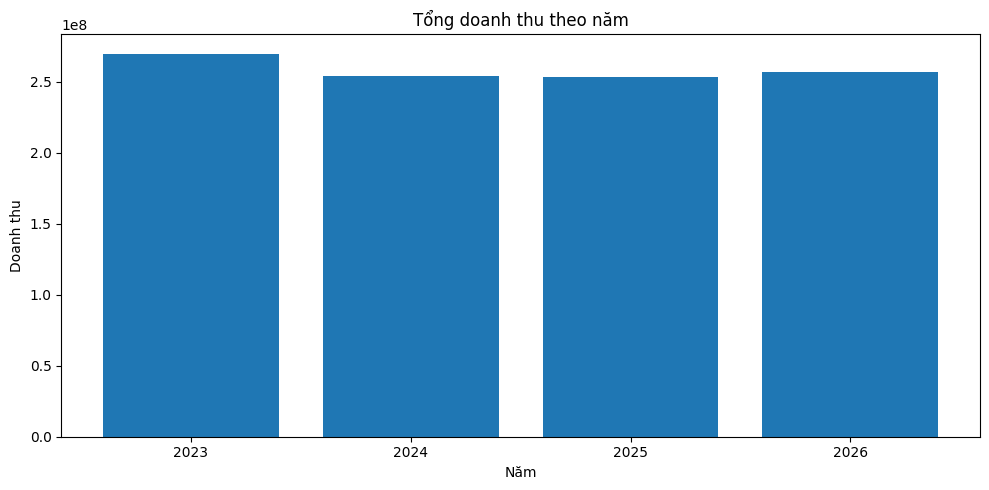

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(df_year['nam'].astype(str), df_year['tong_doanh_thu'])

plt.title('Tổng doanh thu theo năm')
plt.xlabel('Năm')
plt.ylabel('Doanh thu')
plt.tight_layout()
plt.show()

### Nhận xét
Biểu đồ cho thấy **2023 nổi bật nhất về doanh thu**. Doanh thu giảm trong 2024–2025 và tăng trở lại trong 2026, nhưng chưa vượt mức của 2023.

## 4.3. Doanh thu theo năm và quý

In [20]:
query = f'''
SELECT
    nam,
    quy,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan
FROM {TABLE_NAME}
GROUP BY nam, quy
ORDER BY nam, quy
'''

df_quarter = pd.read_sql(query, engine)
hien_thi_vi(df_quarter)

,nam,quy,tong_so_don_hang,tong_doanh_thu,tong_loi_nhuan
0,2023,1,1943,73817232.0,14520310.0
1,2023,2,1826,62048983.0,12719586.0
2,2023,3,1896,65763436.0,12667670.0
3,2023,4,1912,68335373.0,13163212.0
4,2024,1,1876,61390669.0,11939747.0
5,2024,2,1820,64021880.0,12248224.0
6,2024,3,1866,65141181.0,12718516.0
7,2024,4,1892,63308807.0,12339198.0
8,2025,1,1827,60596607.0,12764844.0
9,2025,2,1909,62863982.0,12543766.0


### Nhận xét
- Quý có doanh thu nổi bật nhất là **Q1/2023** với khoảng **73,82 triệu**.
- **Q3/2026** cũng khá cao, khoảng **66,23 triệu**.
- Kết quả theo quý giúp nhìn rõ biến động hơn so với chỉ tổng hợp theo năm.

## 4.4. Phân tích mùa vụ theo tháng

In [21]:
query = f'''
SELECT
    thang,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan
FROM {TABLE_NAME}
GROUP BY thang
ORDER BY thang
'''

df_month = pd.read_sql(query, engine)
hien_thi_vi(df_month)

,thang,tong_so_don_hang,tong_doanh_thu,tong_loi_nhuan
0,1,2571,83916192.0,17025660.0
1,2,2297,83648980.0,16559916.0
2,3,2609,92253429.0,18158990.0
3,4,2386,84915219.0,16289668.0
4,5,2524,83579556.0,16197969.0
5,6,2475,83739658.0,16480800.0
6,7,2514,83110075.0,16359500.0
7,8,2586,97601204.0,18377756.0
8,9,2489,82589779.0,16263722.0
9,10,2453,81772602.0,15614507.0


### Nhận xét
- **Tháng 8** có doanh thu cao nhất, khoảng **97,60 triệu**.
- Tiếp theo là **tháng 12** và **tháng 3**, đều trên **92 triệu**.
- **Tháng 10** có doanh thu thấp nhất, khoảng **81,77 triệu**.
- Đây là tổng hợp cùng tháng của nhiều năm, nên nên hiểu là **mùa vụ**, không phải chuỗi thời gian liên tục.

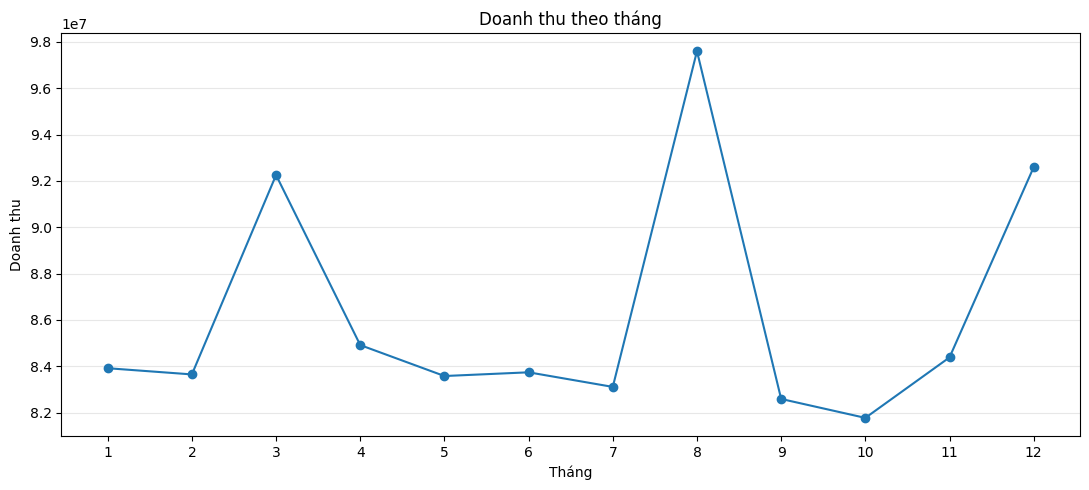

In [22]:
plt.figure(figsize=(11, 5))
plt.plot(df_month['thang'], df_month['tong_doanh_thu'], marker='o')

plt.title('Doanh thu theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Doanh thu')
plt.xticks(df_month['thang'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét
Đường doanh thu thể hiện ba vùng nổi bật ở **tháng 3, tháng 8 và tháng 12**, trong đó tháng 8 là đỉnh cao nhất. Khoảng tháng 9–10 có xu hướng thấp hơn.

Bảng tháng cộng cùng tháng qua các năm nên dùng để xem **mùa vụ**, không gọi là chuỗi thời gian liên tục.

## 4.5. Hiệu quả theo nhóm sản phẩm

In [23]:
query = f'''
SELECT
    nhom_san_pham,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(so_luong) AS tong_so_luong,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan,
    AVG(bien_loi_nhuan) AS bien_loi_nhuan_trung_binh,
    AVG(danh_gia) AS danh_gia_trung_binh
FROM {TABLE_NAME}
GROUP BY nhom_san_pham
ORDER BY tong_doanh_thu DESC
'''

df_category = pd.read_sql(query, engine)
hien_thi_vi(df_category)

,nhom_san_pham,tong_so_don_hang,tong_so_luong,tong_doanh_thu,tong_loi_nhuan,bien_loi_nhuan_trung_binh,danh_gia_trung_binh
0,Electronics,4699,14280,574250789.0,94898862.0,1449.715471,40.540115
1,Home & Kitchen,4194,12886,161863472.0,34608940.0,1917.181688,40.639247
2,Fashion,6092,18821,120158182.0,31338034.0,2348.704038,40.105877
3,Sports,2439,7563,59737705.0,12741945.0,1885.606806,40.593276
4,Beauty,2971,9227,42041634.0,12154189.0,2621.977785,40.554022
5,Groceries,5380,16412,32772559.0,6906444.0,1880.457063,40.629740
6,Toys,2062,6466,25573632.0,5392907.0,1929.019884,40.635306
7,Books,2163,6765,17707113.0,3723657.0,1899.390661,40.343042


### Nhận xét
- **Electronics** dẫn đầu rất mạnh với khoảng **574,25 triệu doanh thu** và **94,90 triệu lợi nhuận**, chiếm hơn một nửa tổng doanh thu.
- **Fashion** có số đơn cao nhất (**6.092 đơn**) nhưng doanh thu thấp hơn nhiều Electronics.
- **Books** có doanh thu thấp nhất trong các nhóm.
- Điều này cho thấy số đơn nhiều chưa chắc tạo ra doanh thu lớn nếu giá trị đơn/sản phẩm thấp hơn.

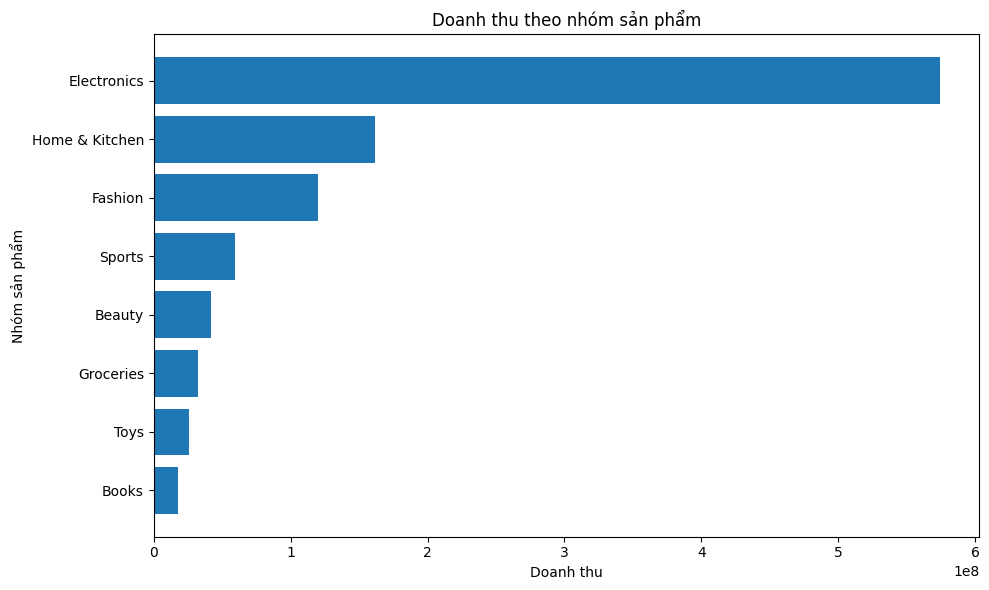

In [24]:
df_category_plot = df_category.sort_values('tong_doanh_thu')

plt.figure(figsize=(10, 6))
plt.barh(df_category_plot['nhom_san_pham'], df_category_plot['tong_doanh_thu'])

plt.title('Doanh thu theo nhóm sản phẩm')
plt.xlabel('Doanh thu')
plt.ylabel('Nhóm sản phẩm')
plt.tight_layout()
plt.show()

### Nhận xét
Biểu đồ làm rõ mức độ vượt trội của **Electronics** so với các nhóm còn lại. Khoảng cách lớn này cho thấy danh mục điện tử là nguồn doanh thu chính của bộ dữ liệu.

### Câu hỏi cần trả lời
- Nhóm sản phẩm nào có doanh thu cao nhất?
- Nhóm đó có đồng thời tạo lợi nhuận cao nhất không?
- Nhóm nào doanh thu cao nhưng biên lợi nhuận thấp?
- Số đơn nhiều có đồng nghĩa với doanh thu cao không?

## 4.6. Top phân nhóm sản phẩm

In [25]:
query = f'''
SELECT TOP 10
    phan_nhom_san_pham,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan,
    SUM(so_luong) AS tong_so_luong
FROM {TABLE_NAME}
GROUP BY phan_nhom_san_pham
ORDER BY tong_doanh_thu DESC
'''

df_subcategory = pd.read_sql(query, engine)
hien_thi_vi(df_subcategory)

,phan_nhom_san_pham,tong_doanh_thu,tong_loi_nhuan,tong_so_luong
0,Mobile,145543289.0,23583090.0,3657
1,Laptop,144488573.0,24174274.0,3649
2,Accessories,142229631.0,23125371.0,3465
3,Headphones,141989296.0,24016127.0,3509
4,Furniture,40992966.0,8441780.0,3266
5,Decor,40414419.0,9027467.0,3216
6,Cookware,40369674.0,8699717.0,3178
7,Appliances,40086413.0,8439976.0,3226
8,Men Clothing,31316094.0,8402360.0,4909
9,Bags,30443065.0,7835246.0,4695


### Nhận xét
Bốn phân nhóm dẫn đầu khá sát nhau:
- **Mobile:** khoảng **145,54 triệu**.
- **Laptop:** khoảng **144,49 triệu**.
- **Accessories:** khoảng **142,23 triệu**.
- **Headphones:** khoảng **141,99 triệu**.

Không có một phân nhóm duy nhất áp đảo hoàn toàn trong top đầu.

## 4.7. Top thương hiệu

In [26]:
query = f'''
SELECT TOP 10
    thuong_hieu,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan
FROM {TABLE_NAME}
GROUP BY thuong_hieu
ORDER BY tong_doanh_thu DESC
'''

df_brand = pd.read_sql(query, engine)
hien_thi_vi(df_brand)

,thuong_hieu,tong_so_don_hang,tong_doanh_thu,tong_loi_nhuan
0,QuickCart,3048,106690331.0,20093756.0
1,EcoLife,3009,106644009.0,20285225.0
2,Zenith,3099,106238755.0,20537995.0
3,Trendify,3014,106122158.0,21266324.0
4,PrimePlus,3004,104458596.0,19861174.0
5,Nova,2988,103518846.0,20908696.0
6,UrbanCo,2986,103258436.0,19807790.0
7,FreshMart,2981,100238486.0,19840020.0
8,ValueMax,2987,99531354.0,19948432.0
9,Apex,2884,97404115.0,19215566.0


### Nhận xét
- **QuickCart** có doanh thu cao nhất trong top thương hiệu, khoảng **106,69 triệu**.
- **Trendify** không đứng đầu doanh thu nhưng có lợi nhuận cao nhất trong top 10, khoảng **21,27 triệu**.
- Doanh thu giữa các thương hiệu top đầu khá sát nhau, nên không nên đánh giá chỉ dựa trên doanh thu.

## 4.8. Phân khúc khách hàng

In [27]:
query = f'''
SELECT
    phan_khuc_khach_hang,
    COUNT(DISTINCT ma_khach_hang) AS tong_so_khach_hang,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan,
    AVG(gia_tri_vong_doi_khach_hang) AS gia_tri_vong_doi_trung_binh,
    AVG(danh_gia) AS danh_gia_trung_binh
FROM {TABLE_NAME}
GROUP BY phan_khuc_khach_hang
ORDER BY tong_doanh_thu DESC
'''

df_customer_segment = pd.read_sql(query, engine)
hien_thi_vi(df_customer_segment)

,phan_khuc_khach_hang,tong_so_khach_hang,tong_so_don_hang,tong_doanh_thu,tong_loi_nhuan,gia_tri_vong_doi_trung_binh,danh_gia_trung_binh
0,Returning,6646,11987,416588711.0,81770228.0,359173.398765,40.505464
1,New,5221,7794,269859666.0,52441894.0,356184.803439,40.289582
2,Loyal,4994,7214,242914957.0,47362602.0,403240.981009,40.553923
3,Premium,2561,3005,104741752.0,20190254.0,473706.286522,40.693844


### Nhận xét
- Nhóm **Returning** đóng góp lớn nhất với **11.987 đơn** và khoảng **416,59 triệu doanh thu**.
- Nhóm **Premium** có quy mô nhỏ hơn nhưng **CLV trung bình cao nhất**, khoảng **473.706**.
- Điều này gợi ý nhóm khách quay lại tạo doanh thu hiện tại lớn, còn Premium có giá trị vòng đời bình quân cao.

## 4.9. Nhóm tuổi khách hàng

In [28]:
query = f'''
SELECT
    CASE
        WHEN tuoi_khach_hang < 25 THEN '18-24'
        WHEN tuoi_khach_hang < 35 THEN '25-34'
        WHEN tuoi_khach_hang < 45 THEN '35-44'
        WHEN tuoi_khach_hang < 55 THEN '45-54'
        ELSE '55+'
    END AS nhom_tuoi,

    COUNT(DISTINCT ma_khach_hang) AS tong_so_khach_hang,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    AVG(tong_tien) AS tong_tien_trung_binh,
    AVG(gia_tri_vong_doi_khach_hang) AS gia_tri_vong_doi_trung_binh

FROM {TABLE_NAME}

GROUP BY
    CASE
        WHEN tuoi_khach_hang < 25 THEN '18-24'
        WHEN tuoi_khach_hang < 35 THEN '25-34'
        WHEN tuoi_khach_hang < 45 THEN '35-44'
        WHEN tuoi_khach_hang < 55 THEN '45-54'
        ELSE '55+'
    END

ORDER BY nhom_tuoi
'''

df_age = pd.read_sql(query, engine)
hien_thi_vi(df_age)

,nhom_tuoi,tong_so_khach_hang,tong_so_don_hang,tong_doanh_thu,tong_tien_trung_binh,gia_tri_vong_doi_trung_binh
0,18-24,3871,5007,170625265.0,34077.344717,379613.791092
1,25-34,5484,8459,294943572.0,34867.427828,387686.182173
2,35-44,5780,9331,322998523.0,34615.638517,379737.394706
3,45-54,4008,5341,181490266.0,33980.577794,372249.862573
4,55+,1687,1862,64047460.0,34397.132116,377177.177229


### Nhận xét
- Nhóm tuổi **35–44** tạo doanh thu cao nhất, khoảng **323,00 triệu**, và có số đơn nhiều nhất (**9.331**).
- Nhóm **25–34** đứng thứ hai.
- Nhóm **55+** có quy mô nhỏ nhất.
- Giá trị đơn trung bình giữa các nhóm tuổi khá gần nhau, khoảng **34 nghìn**, nên khác biệt doanh thu chủ yếu đến từ số lượng đơn/khách hàng.

## 4.10. Top quốc gia

In [29]:
query = f'''
SELECT TOP 10
    quoc_gia,
    COUNT(DISTINCT ma_khach_hang) AS tong_so_khach_hang,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan
FROM {TABLE_NAME}
GROUP BY quoc_gia
ORDER BY tong_doanh_thu DESC
'''

df_country = pd.read_sql(query, engine)
hien_thi_vi(df_country)

,quoc_gia,tong_so_khach_hang,tong_so_don_hang,tong_doanh_thu,tong_loi_nhuan
0,Canada,2618,3099,108351583.0,20582187.0
1,United States,2594,3047,107359661.0,21469963.0
2,Saudi Arabia,2550,2984,107018527.0,21000492.0
3,United Kingdom,2604,3083,106581459.0,20485666.0
4,Australia,2548,3001,105252691.0,20822258.0
5,India,2544,2972,103405594.0,20276401.0
6,France,2575,3023,102733703.0,19726292.0
7,UAE,2515,2964,100534196.0,19540568.0
8,Pakistan,2474,2870,97906791.0,18942328.0
9,Germany,2515,2957,94960881.0,18918823.0


### Nhận xét
- **Canada** có doanh thu cao nhất, khoảng **108,35 triệu**.
- **United States** có lợi nhuận cao nhất trong top 10, khoảng **21,47 triệu**.
- Doanh thu giữa nhiều quốc gia top đầu khá gần nhau, không có quốc gia nào vượt trội tuyệt đối.

## 4.11. Top thành phố

In [30]:
query = f'''
SELECT TOP 10
    thanh_pho,
    quoc_gia,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan
FROM {TABLE_NAME}
GROUP BY thanh_pho, quoc_gia
ORDER BY tong_doanh_thu DESC
'''

df_city = pd.read_sql(query, engine)
hien_thi_vi(df_city)

,thanh_pho,quoc_gia,tong_so_don_hang,tong_doanh_thu,tong_loi_nhuan
0,Toronto,Saudi Arabia,331,13485161.0,2618010.0
1,Dubai,India,316,12926983.0,2513017.0
2,Paris,United States,335,12862901.0,2819446.0
3,Riyadh,Pakistan,322,12744484.0,2440130.0
4,Dubai,France,313,12662835.0,2342828.0
5,Dubai,Australia,317,12407397.0,2569974.0
6,Sydney,Canada,309,12351938.0,2369923.0
7,Dubai,UAE,320,12219723.0,2435914.0
8,Toronto,United Kingdom,312,12053226.0,2434586.0
9,Karachi,United Kingdom,331,11909254.0,2211371.0


### Nhận xét
Kết quả xuất hiện nhiều cặp **thành phố – quốc gia không hợp lý**, ví dụ `Toronto – Saudi Arabia`, `Paris – United States`, `Dubai – India`. Đây là dấu hiệu cần kiểm tra chất lượng dữ liệu địa lý trước khi dùng phần `thanh_pho`/`quoc_gia` để ra quyết định kinh doanh.

## 4.12. Phương thức thanh toán

In [31]:
query = f'''
SELECT
    phuong_thuc_thanh_toan,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    AVG(tong_tien) AS tong_tien_trung_binh
FROM {TABLE_NAME}
GROUP BY phuong_thuc_thanh_toan
ORDER BY tong_so_don_hang DESC
'''

df_payment = pd.read_sql(query, engine)
hien_thi_vi(df_payment)

,phuong_thuc_thanh_toan,tong_so_don_hang,tong_doanh_thu,tong_tien_trung_binh
0,Credit Card,5080,174168047.0,34285.048622
1,PayPal,5006,176158704.0,35189.513384
2,Bank Transfer,5002,175865636.0,35159.063575
3,Wallet,4977,170562309.0,34270.104280
4,Debit Card,4969,166459975.0,33499.693097
5,Cash on Delivery,4966,170890415.0,34412.085179


### Nhận xét
- Các phương thức thanh toán có số đơn khá cân bằng.
- **Credit Card** có nhiều đơn nhất (**5.080**).
- **PayPal** có doanh thu cao nhất, khoảng **176,16 triệu**, sát với Bank Transfer.
- Chênh lệch giá trị đơn trung bình giữa các phương thức không quá lớn.

## 4.13. Loại thiết bị

In [32]:
query = f'''
SELECT
    loai_thiet_bi,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    COUNT(DISTINCT ma_khach_hang) AS tong_so_khach_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    AVG(tong_tien) AS tong_tien_trung_binh
FROM {TABLE_NAME}
GROUP BY loai_thiet_bi
ORDER BY tong_so_don_hang DESC
'''

df_device = pd.read_sql(query, engine)
hien_thi_vi(df_device)

,loai_thiet_bi,tong_so_don_hang,tong_so_khach_hang,tong_doanh_thu,tong_tien_trung_binh
0,Mobile,18538,7833,646444464.0,34871.316431
1,Desktop,9085,5716,308060369.0,33908.681233
2,Tablet,2377,2089,79600253.0,33487.695835


### Nhận xét
- **Mobile** chiếm **18.538/30.000 đơn**, tương đương khoảng **61,8%** tổng đơn hàng.
- Doanh thu từ Mobile khoảng **646,44 triệu**, cũng chiếm hơn **62%** tổng doanh thu.
- Mobile là kênh thiết bị quan trọng nhất trong bộ dữ liệu; Desktop đứng thứ hai và Tablet thấp hơn rõ rệt.

## 4.14. Giảm giá và lợi nhuận

In [33]:
query = f'''
SELECT
    CASE
        WHEN ty_le_giam_gia = 0 THEN '0%'
        WHEN ty_le_giam_gia <= 10 THEN '1-10%'
        WHEN ty_le_giam_gia <= 20 THEN '11-20%'
        WHEN ty_le_giam_gia <= 30 THEN '21-30%'
        ELSE 'Trên 30%'
    END AS nhom_giam_gia,

    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    AVG(ty_le_giam_gia) AS ty_le_giam_gia_trung_binh,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan,
    AVG(bien_loi_nhuan) AS bien_loi_nhuan_trung_binh

FROM {TABLE_NAME}

GROUP BY
    CASE
        WHEN ty_le_giam_gia = 0 THEN '0%'
        WHEN ty_le_giam_gia <= 10 THEN '1-10%'
        WHEN ty_le_giam_gia <= 20 THEN '11-20%'
        WHEN ty_le_giam_gia <= 30 THEN '21-30%'
        ELSE 'Trên 30%'
    END

ORDER BY ty_le_giam_gia_trung_binh
'''

df_discount = pd.read_sql(query, engine)
hien_thi_vi(df_discount)

,nhom_giam_gia,tong_so_don_hang,ty_le_giam_gia_trung_binh,tong_doanh_thu,tong_loi_nhuan,bien_loi_nhuan_trung_binh
0,0%,7882,0,306007629.0,68229482.0,2280.141842
1,1-10%,8373,7,300885287.0,61507810.0,2109.965007
2,11-20%,7768,17,257231663.0,45981095.0,1861.043898
3,21-30%,4184,27,121150354.0,19410934.0,1687.182839
4,Trên 30%,1793,36,48830153.0,6635657.0,1449.175683


### Nhận xét
Có xu hướng rất rõ trong dữ liệu:
- Nhóm **0% giảm giá** có doanh thu và lợi nhuận cao nhất.
- Khi mức giảm giá tăng, **doanh thu, lợi nhuận và biên lợi nhuận trung bình đều giảm**.
- Nhóm **trên 30%** có kết quả thấp nhất.

Tuy nhiên đây mới là mối liên hệ mô tả; còn phải xem số đơn, loại sản phẩm và cơ cấu khách hàng trước khi kết luận giảm giá là nguyên nhân.

### Cần kiểm tra đồng thời
- Tổng số đơn hàng
- Tổng doanh thu
- Tổng lợi nhuận
- Biên lợi nhuận trung bình

Không kết luận giảm giá tốt chỉ vì doanh thu cao. Cần xem thêm cơ cấu sản phẩm, khách hàng và số lượng đơn.

## 4.15. Phương thức vận chuyển

In [34]:
query = f'''
SELECT
    phuong_thuc_van_chuyen,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    AVG(chi_phi_van_chuyen) AS chi_phi_van_chuyen_trung_binh,
    AVG(CAST(so_ngay_giao_hang AS FLOAT)) AS so_ngay_giao_hang_trung_binh,
    AVG(CAST(danh_gia AS FLOAT)) AS danh_gia_trung_binh,
    SUM(tong_tien) AS tong_doanh_thu
FROM {TABLE_NAME}
GROUP BY phuong_thuc_van_chuyen
ORDER BY tong_so_don_hang DESC
'''

df_shipping = pd.read_sql(query, engine)
hien_thi_vi(df_shipping)

,phuong_thuc_van_chuyen,tong_so_don_hang,chi_phi_van_chuyen_trung_binh,so_ngay_giao_hang_trung_binh,danh_gia_trung_binh,tong_doanh_thu
0,Standard,16420,626.163764,5.284653,40.373203,562342322.0
1,Express,7914,1355.482563,3.309704,40.638110,275972389.0
2,Pickup,2955,630.515059,5.285279,40.548223,97808883.0
3,Same Day,2711,1980.790852,1.665437,40.589819,97981492.0


## 4.16. Khu vực kho hàng

In [35]:
query = f'''
SELECT
    khu_vuc_kho,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    AVG(chi_phi_van_chuyen) AS chi_phi_van_chuyen_trung_binh,
    AVG(CAST(so_ngay_giao_hang AS FLOAT)) AS so_ngay_giao_hang_trung_binh,
    AVG(CAST(danh_gia AS FLOAT)) AS danh_gia_trung_binh
FROM {TABLE_NAME}
GROUP BY khu_vuc_kho
ORDER BY so_ngay_giao_hang_trung_binh
'''

df_warehouse = pd.read_sql(query, engine)
hien_thi_vi(df_warehouse)

,khu_vuc_kho,tong_so_don_hang,chi_phi_van_chuyen_trung_binh,so_ngay_giao_hang_trung_binh,danh_gia_trung_binh
0,West,6060,950.709901,4.363861,40.470462
1,East,5990,936.588982,4.410184,40.521202
2,Central,5981,946.414479,4.439893,40.634342
3,South,6035,941.680365,4.478873,40.371997
4,North,5934,931.408493,4.491574,40.401921


### Nhận xét
- **West** giao nhanh nhất, trung bình khoảng **4,36 ngày**, nhưng có chi phí vận chuyển trung bình cao nhất trong các khu vực được hiển thị.
- **North** giao chậm nhất, khoảng **4,49 ngày**, nhưng chi phí vận chuyển trung bình thấp hơn.
- Điểm đánh giá giữa các khu vực khá sát nhau.

## 4.17. Số ngày giao hàng và điểm đánh giá

In [36]:
query = f'''
SELECT
    CASE
        WHEN so_ngay_giao_hang <= 2 THEN '0-2 ngày'
        WHEN so_ngay_giao_hang <= 5 THEN '3-5 ngày'
        WHEN so_ngay_giao_hang <= 7 THEN '6-7 ngày'
        ELSE 'Trên 7 ngày'
    END AS nhom_thoi_gian_giao_hang,

    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    AVG(CAST(so_ngay_giao_hang AS FLOAT)) AS so_ngay_giao_hang_trung_binh,
    AVG(CAST(danh_gia AS FLOAT)) AS danh_gia_trung_binh

FROM {TABLE_NAME}

GROUP BY
    CASE
        WHEN so_ngay_giao_hang <= 2 THEN '0-2 ngày'
        WHEN so_ngay_giao_hang <= 5 THEN '3-5 ngày'
        WHEN so_ngay_giao_hang <= 7 THEN '6-7 ngày'
        ELSE 'Trên 7 ngày'
    END

ORDER BY so_ngay_giao_hang_trung_binh
'''

df_delivery_rating = pd.read_sql(query, engine)
hien_thi_vi(df_delivery_rating)

,nhom_thoi_gian_giao_hang,tong_so_don_hang,so_ngay_giao_hang_trung_binh,danh_gia_trung_binh
0,0-2 ngày,6385,1.162412,40.560376
1,3-5 ngày,13628,4.054153,40.713311
2,6-7 ngày,7065,6.417551,40.708280
3,Trên 7 ngày,2922,8.585900,38.663244


### Nhận xét
- Nhóm giao **trên 7 ngày** có điểm đánh giá trung bình khoảng **38,66**, thấp hơn rõ rệt các nhóm giao nhanh hơn (khoảng **40,56–40,71**).
- Kết quả cho thấy **có dấu hiệu liên hệ giữa giao hàng lâu và rating thấp hơn**, nhưng chưa đủ để kết luận quan hệ nhân quả.

## 4.18. Trạng thái đơn hàng

In [37]:
query = f'''
SELECT
    trang_thai_don_hang,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan
FROM {TABLE_NAME}
GROUP BY trang_thai_don_hang
ORDER BY tong_so_don_hang DESC
'''

df_status = pd.read_sql(query, engine)
hien_thi_vi(df_status)

,trang_thai_don_hang,tong_so_don_hang,tong_doanh_thu,tong_loi_nhuan
0,Delivered,19497,671363184.0,131335801.0
1,Shipped,3469,117673542.0,22736731.0
2,Returned,3033,103141227.0,20741271.0
3,Processing,2230,77020241.0,14919951.0
4,Cancelled,1771,64906892.0,12031224.0


### Nhận xét
- `Delivered` chiếm **19.497 đơn**, khoảng **65%** tổng số đơn.
- Có **3.033 đơn Returned** và **1.771 đơn Cancelled**.
- Một điểm rất quan trọng: doanh thu trong các KPI trước đang cộng tất cả trạng thái đơn. Nếu muốn tính **doanh thu thực nhận**, cần thống nhất business rule xem có loại Returned/Cancelled hay không.

## 4.19. Top khách hàng theo giá trị vòng đời (CLV)

In [38]:
query = f'''
SELECT TOP 10
    ma_khach_hang,
    MAX(gia_tri_vong_doi_khach_hang) AS gia_tri_vong_doi_khach_hang,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan,
    AVG(danh_gia) AS danh_gia_trung_binh
FROM {TABLE_NAME}
GROUP BY ma_khach_hang
ORDER BY gia_tri_vong_doi_khach_hang DESC
'''

df_clv_top = pd.read_sql(query, engine)
hien_thi_vi(df_clv_top)

,ma_khach_hang,gia_tri_vong_doi_khach_hang,tong_so_don_hang,tong_doanh_thu,tong_loi_nhuan,danh_gia_trung_binh
0,CUST003274,4989269.0,5,402273.0,27654.0,41.200000
1,CUST000084,4944265.0,3,544308.0,84388.0,39.333333
2,CUST005232,4935047.0,5,429818.0,29793.0,43.400000
3,CUST002831,4911808.0,3,347816.0,34019.0,41.333333
4,CUST007183,4895525.0,4,365963.0,57265.0,44.500000
5,CUST004837,4886586.0,5,242087.0,73793.0,40.000000
6,CUST004778,4870496.0,5,353132.0,34767.0,44.400000
7,CUST002565,4865361.0,6,330370.0,71684.0,34.500000
8,CUST005930,4854702.0,4,403841.0,44850.0,43.500000
9,CUST008260,4817688.0,4,321965.0,22104.0,44.500000


### Nhận xét
- Khách hàng có CLV cao nhất là **CUST003274**, khoảng **4,99 triệu**.
- Một số khách có CLV rất cao nhưng số đơn chỉ 3–6 đơn, cho thấy CLV không chỉ phản ánh số lần mua hiện tại.
- Nên dùng bảng này để xác định nhóm khách cần chăm sóc/giữ chân, nhưng cần xác nhận cách cột CLV được tạo.

# PHẦN 5. PHÂN NHÓM KHÁCH HÀNG 

## 5.1. Tạo bảng hành vi khách hàng


In [39]:
query = f'''
WITH customer_data AS (
    SELECT
        ma_khach_hang,
        COUNT(DISTINCT ma_don_hang) AS tan_suat_mua,
        SUM(tong_tien) AS tong_chi_tieu,
        SUM(loi_nhuan) AS tong_loi_nhuan,
        AVG(tong_tien) AS tong_tien_trung_binh,
        MAX(gia_tri_vong_doi_khach_hang) AS gia_tri_vong_doi_khach_hang,
        AVG(danh_gia) AS danh_gia_trung_binh
    FROM {TABLE_NAME}
    GROUP BY ma_khach_hang
)

SELECT TOP 20
    *
FROM customer_data
ORDER BY tong_chi_tieu DESC
'''

df_customer_value = pd.read_sql(query, engine)
hien_thi_vi(df_customer_value)

,ma_khach_hang,tan_suat_mua,tong_chi_tieu,tong_loi_nhuan,tong_tien_trung_binh,gia_tri_vong_doi_khach_hang,danh_gia_trung_binh
0,CUST000459,3,1071212.0,181707.0,357070.666667,2320356.0,39.666667
1,CUST006906,9,959996.0,105782.0,106666.222222,3597164.0,38.222222
2,CUST000025,4,930843.0,192983.0,232710.750000,3072132.0,42.000000
3,CUST000381,6,903520.0,170757.0,150586.666667,1344919.0,43.333333
4,CUST000677,8,868257.0,106844.0,108532.125000,2528787.0,44.000000
5,CUST008949,5,849690.0,80115.0,169938.000000,1904002.0,34.600000
6,CUST001750,9,845781.0,133686.0,93975.666667,2065064.0,42.000000
7,CUST003335,7,835287.0,75940.0,119326.714286,2492318.0,41.285714
8,CUST005767,4,827202.0,28694.0,206800.500000,500000.0,37.500000
9,CUST005303,8,808293.0,140221.0,101036.625000,2250928.0,40.875000


### Nhận xét
- Khách có tổng chi tiêu cao nhất là **CUST000459**, khoảng **1,071 triệu**, dù chỉ có **3 lần mua**.
- Có khách mua nhiều lần hơn nhưng tổng chi tiêu thấp hơn.
- Vì vậy hai biến `tan_suat_mua` (tần suất) và `tong_chi_tieu` (chi tiêu) bổ sung cho nhau và phù hợp để tạo rule phân nhóm khách hàng.

## 5.2. Phân nhóm khách hàng bằng quy tắc kinh doanh


- **Giá trị cao:** tần suất mua và tổng chi tiêu đều >= trung bình.
- **Mua thường xuyên / Tiềm năng:** tần suất cao nhưng tổng chi tiêu dưới trung bình.
- **Chi tiêu lớn / Không thường xuyên:** tổng chi tiêu cao nhưng tần suất dưới trung bình.
- **Tương tác thấp:** cả hai dưới trung bình.

In [40]:
query = f'''
WITH customer_data AS (
    SELECT
        ma_khach_hang,
        COUNT(DISTINCT ma_don_hang) AS tan_suat_mua,
        SUM(tong_tien) AS tong_chi_tieu,
        SUM(loi_nhuan) AS tong_loi_nhuan,
        MAX(gia_tri_vong_doi_khach_hang) AS gia_tri_vong_doi_khach_hang
    FROM {TABLE_NAME}
    GROUP BY ma_khach_hang
),

customer_average AS (
    SELECT
        AVG(CAST(tan_suat_mua AS FLOAT)) AS tan_suat_mua_trung_binh,
        AVG(tong_chi_tieu) AS chi_tieu_trung_binh
    FROM customer_data
)

SELECT
    c.ma_khach_hang,
    c.tan_suat_mua,
    c.tong_chi_tieu,
    c.tong_loi_nhuan,
    c.gia_tri_vong_doi_khach_hang,

    CASE
        WHEN c.tan_suat_mua >= a.tan_suat_mua_trung_binh
         AND c.tong_chi_tieu >= a.chi_tieu_trung_binh
            THEN 'Giá trị cao'

        WHEN c.tan_suat_mua >= a.tan_suat_mua_trung_binh
         AND c.tong_chi_tieu < a.chi_tieu_trung_binh
            THEN 'Mua thường xuyên / Tiềm năng'

        WHEN c.tan_suat_mua < a.tan_suat_mua_trung_binh
         AND c.tong_chi_tieu >= a.chi_tieu_trung_binh
            THEN 'Chi tiêu lớn / Không thường xuyên'

        ELSE 'Tương tác thấp'
    END AS nhom_khach_hang

FROM customer_data c
CROSS JOIN customer_average a
ORDER BY c.tong_chi_tieu DESC
'''

df_customer_group = pd.read_sql(query, engine)
hien_thi_vi(df_customer_group.head(20))

,ma_khach_hang,tan_suat_mua,tong_chi_tieu,tong_loi_nhuan,gia_tri_vong_doi_khach_hang,nhom_khach_hang
0,CUST000459,3,1071212.0,181707.0,2320356.0,Chi tiêu l?n / Không thu?ng xuyên
1,CUST006906,9,959996.0,105782.0,3597164.0,Giá tr? cao
2,CUST000025,4,930843.0,192983.0,3072132.0,Giá tr? cao
3,CUST000381,6,903520.0,170757.0,1344919.0,Giá tr? cao
4,CUST000677,8,868257.0,106844.0,2528787.0,Giá tr? cao
5,CUST008949,5,849690.0,80115.0,1904002.0,Giá tr? cao
6,CUST001750,9,845781.0,133686.0,2065064.0,Giá tr? cao
7,CUST003335,7,835287.0,75940.0,2492318.0,Giá tr? cao
8,CUST005767,4,827202.0,28694.0,500000.0,Giá tr? cao
9,CUST005303,8,808293.0,140221.0,2250928.0,Giá tr? cao


### Nhận xét
Rule đang phân khách dựa trên **tần suất mua** và **tổng chi tiêu** so với mức trung bình toàn bộ khách hàng. Ví dụ, khách chi tiêu rất cao nhưng tần suất thấp sẽ vào nhóm **Chi tiêu lớn / Không thường xuyên**, thay vì nhóm Giá trị cao.

## 5.3. Tổng hợp từng nhóm

In [41]:
query = f'''
WITH customer_data AS (
    SELECT
        ma_khach_hang,
        COUNT(DISTINCT ma_don_hang) AS tan_suat_mua,
        SUM(tong_tien) AS tong_chi_tieu,
        SUM(loi_nhuan) AS tong_loi_nhuan,
        MAX(gia_tri_vong_doi_khach_hang) AS gia_tri_vong_doi_khach_hang
    FROM {TABLE_NAME}
    GROUP BY ma_khach_hang
),

customer_average AS (
    SELECT
        AVG(CAST(tan_suat_mua AS FLOAT)) AS tan_suat_mua_trung_binh,
        AVG(tong_chi_tieu) AS chi_tieu_trung_binh
    FROM customer_data
),

customer_group AS (
    SELECT
        c.ma_khach_hang,
        c.tan_suat_mua,
        c.tong_chi_tieu,
        c.tong_loi_nhuan,
        c.gia_tri_vong_doi_khach_hang,

        CASE
            WHEN c.tan_suat_mua >= a.tan_suat_mua_trung_binh
             AND c.tong_chi_tieu >= a.chi_tieu_trung_binh
                THEN 'Giá trị cao'

            WHEN c.tan_suat_mua >= a.tan_suat_mua_trung_binh
             AND c.tong_chi_tieu < a.chi_tieu_trung_binh
                THEN 'Mua thường xuyên / Tiềm năng'

            WHEN c.tan_suat_mua < a.tan_suat_mua_trung_binh
             AND c.tong_chi_tieu >= a.chi_tieu_trung_binh
                THEN 'Chi tiêu lớn / Không thường xuyên'

            ELSE 'Tương tác thấp'
        END AS nhom_khach_hang

    FROM customer_data c
    CROSS JOIN customer_average a
)

SELECT
    nhom_khach_hang,
    COUNT(*) AS tong_so_khach_hang,
    AVG(CAST(tan_suat_mua AS FLOAT)) AS tan_suat_mua_trung_binh,
    AVG(tong_chi_tieu) AS chi_tieu_trung_binh,
    SUM(tong_chi_tieu) AS tong_doanh_thu,
    SUM(tong_loi_nhuan) AS tong_loi_nhuan,
    AVG(gia_tri_vong_doi_khach_hang) AS gia_tri_vong_doi_trung_binh
FROM customer_group
GROUP BY nhom_khach_hang
ORDER BY tong_doanh_thu DESC
'''

df_group_summary = pd.read_sql(query, engine)
hien_thi_vi(df_group_summary)

,nhom_khach_hang,tong_so_khach_hang,tan_suat_mua_trung_binh,chi_tieu_trung_binh,tong_doanh_thu,tong_loi_nhuan,gia_tri_vong_doi_trung_binh
0,Giá tr? cao,2178,5.388430,250716.657025,546060879.0,99223543.0,1.483246e+06
1,Chi tiêu l?n / Không thu?ng xuyên,950,2.547368,220125.737895,209119451.0,35156348.0,1.602596e+06
2,Tuong tác th?p,3919,2.110998,41296.692268,161841737.0,38052999.0,4.061025e+05
3,Mua thu?ng xuyên / Ti?m nang,1636,4.627751,71566.637531,117083019.0,29332088.0,5.296453e+05


### Nhận xét
- **Giá trị cao:** 2.178 khách nhưng tạo khoảng **546,06 triệu doanh thu**, hơn **52% tổng doanh thu**.
- **Tương tác thấp:** đông nhất với **3.919 khách**, nhưng doanh thu chỉ khoảng **161,84 triệu**.
- **Chi tiêu lớn / Không thường xuyên:** chỉ 950 khách nhưng CLV trung bình rất cao, khoảng **1,60 triệu**.
- Đây là cơ sở tốt để ưu tiên chiến lược chăm sóc theo từng nhóm.

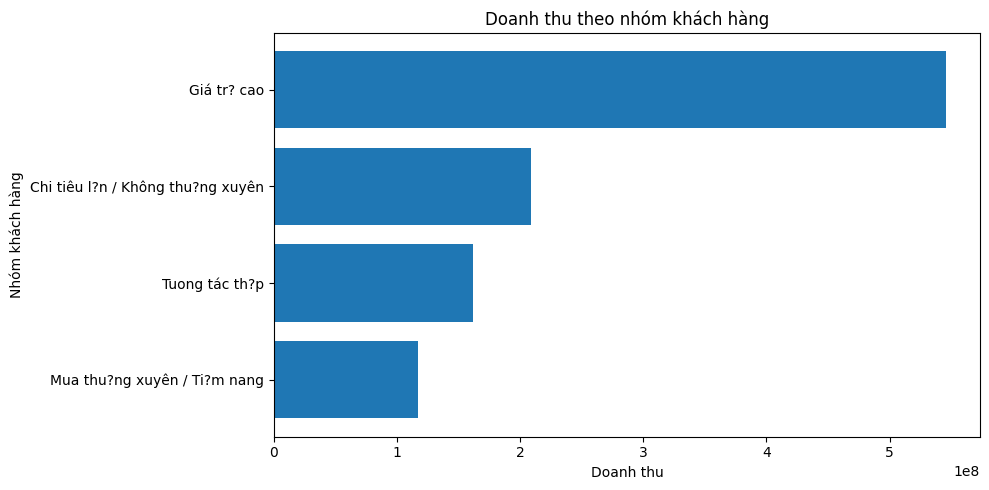

In [42]:
df_group_plot = df_group_summary.sort_values('tong_doanh_thu')

plt.figure(figsize=(10, 5))
plt.barh(df_group_plot['nhom_khach_hang'], df_group_plot['tong_doanh_thu'])

plt.title('Doanh thu theo nhóm khách hàng')
plt.xlabel('Doanh thu')
plt.ylabel('Nhóm khách hàng')
plt.tight_layout()
plt.show()

### Nhận xét
Biểu đồ nhấn mạnh nhóm **Giá trị cao** là nguồn doanh thu lớn nhất. Nhóm **Mua thường xuyên / Tiềm năng** có doanh thu hiện tại thấp hơn nhưng có tần suất mua cao, phù hợp cho chiến lược tăng giá trị giỏ hàng.

### Hướng hành động
- **Giá trị cao:** ưu tiên giữ chân, chương trình khách hàng thân thiết, ưu đãi cá nhân hóa.
- **Mua thường xuyên / Tiềm năng:** tăng giá trị giỏ hàng bằng bán kèm hoặc gợi ý sản phẩm.
- **Chi tiêu lớn / Không thường xuyên:** tăng tần suất quay lại.
- **Tương tác thấp:** đánh giá tiềm năng trước khi dùng nhiều ngân sách marketing.

# PHẦN 6. NHẬN ĐỊNH KINH DOANH

## 6.1. Nhóm sản phẩm: so sánh doanh thu và lợi nhuận

In [43]:
query = f'''
SELECT
    nhom_san_pham,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan,
    AVG(bien_loi_nhuan) AS bien_loi_nhuan_trung_binh
FROM {TABLE_NAME}
GROUP BY nhom_san_pham
ORDER BY tong_doanh_thu DESC
'''

df_revenue_profit_category = pd.read_sql(query, engine)
hien_thi_vi(df_revenue_profit_category)

,nhom_san_pham,tong_doanh_thu,tong_loi_nhuan,bien_loi_nhuan_trung_binh
0,Electronics,574250789.0,94898862.0,1449.715471
1,Home & Kitchen,161863472.0,34608940.0,1917.181688
2,Fashion,120158182.0,31338034.0,2348.704038
3,Sports,59737705.0,12741945.0,1885.606806
4,Beauty,42041634.0,12154189.0,2621.977785
5,Groceries,32772559.0,6906444.0,1880.457063
6,Toys,25573632.0,5392907.0,1929.019884
7,Books,17707113.0,3723657.0,1899.390661


### Nhận xét
Dựa trên kết quả phân tích category phía trên, **Electronics** vừa có doanh thu cao nhất (khoảng **574,25 triệu**) vừa có tổng lợi nhuận cao nhất (khoảng **94,90 triệu**). Tuy nhiên biên lợi nhuận trung bình của nhóm này không cao nhất, nên cần tách rõ **quy mô doanh thu** và **hiệu quả biên lợi nhuận**.

## 6.2. Nhóm giảm giá có biên lợi nhuận thấp

In [44]:
query = f'''
SELECT
    CASE
        WHEN ty_le_giam_gia = 0 THEN '0%'
        WHEN ty_le_giam_gia <= 10 THEN '1-10%'
        WHEN ty_le_giam_gia <= 20 THEN '11-20%'
        WHEN ty_le_giam_gia <= 30 THEN '21-30%'
        ELSE 'Trên 30%'
    END AS nhom_giam_gia,

    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    SUM(tong_tien) AS tong_doanh_thu,
    SUM(loi_nhuan) AS tong_loi_nhuan,
    AVG(bien_loi_nhuan) AS bien_loi_nhuan_trung_binh

FROM {TABLE_NAME}

GROUP BY
    CASE
        WHEN ty_le_giam_gia = 0 THEN '0%'
        WHEN ty_le_giam_gia <= 10 THEN '1-10%'
        WHEN ty_le_giam_gia <= 20 THEN '11-20%'
        WHEN ty_le_giam_gia <= 30 THEN '21-30%'
        ELSE 'Trên 30%'
    END

ORDER BY bien_loi_nhuan_trung_binh
'''

df_discount_profit = pd.read_sql(query, engine)
hien_thi_vi(df_discount_profit)

,nhom_giam_gia,tong_so_don_hang,tong_doanh_thu,tong_loi_nhuan,bien_loi_nhuan_trung_binh
0,Trên 30%,1793,48830153.0,6635657.0,1449.175683
1,21-30%,4184,121150354.0,19410934.0,1687.182839
2,11-20%,7768,257231663.0,45981095.0,1861.043898
3,1-10%,8373,300885287.0,61507810.0,2109.965007
4,0%,7882,306007629.0,68229482.0,2280.141842


### Nhận xét
Kết quả cùng logic với phần giảm giá phía trên: nhóm **trên 30% giảm giá** có biên lợi nhuận trung bình thấp nhất, còn nhóm **0%** cao nhất. Đây là tín hiệu để kiểm tra sâu hơn chính sách khuyến mãi, nhưng chưa chứng minh giảm giá trực tiếp gây giảm lợi nhuận.

## 6.3. Phương thức vận chuyển cần chú ý

In [45]:
query = f'''
SELECT
    phuong_thuc_van_chuyen,
    COUNT(DISTINCT ma_don_hang) AS tong_so_don_hang,
    AVG(CAST(so_ngay_giao_hang AS FLOAT)) AS so_ngay_giao_hang_trung_binh,
    AVG(chi_phi_van_chuyen) AS chi_phi_van_chuyen_trung_binh,
    AVG(CAST(danh_gia AS FLOAT)) AS danh_gia_trung_binh
FROM {TABLE_NAME}
GROUP BY phuong_thuc_van_chuyen
ORDER BY danh_gia_trung_binh
'''

df_shipping_experience = pd.read_sql(query, engine)
hien_thi_vi(df_shipping_experience)

,phuong_thuc_van_chuyen,tong_so_don_hang,so_ngay_giao_hang_trung_binh,chi_phi_van_chuyen_trung_binh,danh_gia_trung_binh
0,Standard,16420,5.284653,626.163764,40.373203
1,Pickup,2955,5.285279,630.515059,40.548223
2,Same Day,2711,1.665437,1980.790852,40.589819
3,Express,7914,3.309704,1355.482563,40.638110


# PHẦN 7. KẾT LUẬN

## 7.1. Kết luận dự án

### Quy mô dữ liệu
- Số dòng: **30.000**.
- Số đơn: **30.000**.
- Số khách hàng: **8.683**.
- Số sản phẩm: **2.500**.
- Giai đoạn dữ liệu: **2023–2026**.

### Kết quả kinh doanh
- Tổng doanh thu: khoảng **1,034 tỷ**.
- Tổng lợi nhuận: khoảng **201,765 triệu**.
- Năm có doanh thu cao nhất: **2023**.
- Tháng có doanh thu cao nhất khi cộng gộp các năm: **tháng 8**.

### Sản phẩm
- Nhóm doanh thu cao nhất: **Electronics**.
- Electronics cũng có tổng lợi nhuận cao nhất, nhưng không có biên lợi nhuận trung bình cao nhất.
- Fashion có nhiều đơn hơn Electronics nhưng doanh thu thấp hơn đáng kể.

### Khách hàng
- Phân khúc `Returning` tạo doanh thu lớn nhất.
- Nhóm **Giá trị cao** tạo hơn một nửa doanh thu theo rule segmentation.
- Nhóm **Tương tác thấp** có số khách đông nhất nhưng doanh thu bình quân thấp hơn.

### Giảm giá
- Trong dữ liệu hiện tại, mức giảm giá cao hơn đi cùng doanh thu/lợi nhuận/biên lợi nhuận thấp hơn.
- Đây là quan hệ mô tả, chưa chứng minh nguyên nhân.

### Vận chuyển và trải nghiệm
- Nhóm giao trên 7 ngày có rating thấp hơn các nhóm giao nhanh hơn.
- Cần chạy lại các cell Shipping Method chưa lưu output để xác định phương thức cụ thể cần chú ý.
- Dữ liệu City–Country có dấu hiệu không nhất quán và cần làm sạch trước khi phân tích địa lý.

